## Feature Engineering + Further Addressing Imbalance
* Combining numerical columns (sq/area columns)
* Engineer features to indicate high value houses (Garage Area/Garage Cars)
* Oversampling to boost up class 0 (<$100k)
* AdaBoost/CatBoost due to high number of categorical features (especially post-encoding)

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

from sklearn.ensemble import AdaBoostClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import RandomOverSampler, SMOTE, SMOTENC
from imblearn.pipeline import Pipeline as pipelineIM

from IPython.display import HTML, display
import tabulate

### Loading Dataset
* All columns (numerical + nominal categorical + ordinal categorical) w/ encoding

In [16]:
#importing module that wraps preprocessing steps
import Housing_Preprocessing as hp

In [19]:
#reimport if necessary (edit file after already imported)
import importlib
importlib.reload(hp)

<module 'Housing_Preprocessing' from '/Users/Temp/Data4381/Housing_Preprocessing.py'>

In [20]:
#loading the dataset/applying preprocessing
df=hp.full_df_prepared('AmesHousing.csv')
df

,Lot Frontage,Lot Area,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,...,Fireplace Qu,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Overall Qual,Overall Cond,Price Bins
0,141.0,31770,1960,1960,112.0,639.0,0.0,441.0,1080.0,1656,...,1.0,0.0,2.0,2.0,1.0,4.0,4.0,6,5,$180k-$260k
1,80.0,11622,1961,1961,0.0,468.0,144.0,270.0,882.0,896,...,5.0,2.0,2.0,2.0,0.0,4.0,1.0,5,6,$100k-$180k
2,81.0,14267,1958,1958,108.0,923.0,0.0,406.0,1329.0,1329,...,5.0,2.0,2.0,2.0,0.0,4.0,4.0,6,6,$100k-$180k
3,93.0,11160,1968,1968,0.0,1065.0,0.0,1045.0,2110.0,2110,...,2.0,0.0,2.0,2.0,0.0,4.0,4.0,7,5,$180k-$260k
4,74.0,13830,1997,1998,0.0,791.0,0.0,137.0,928.0,928,...,2.0,0.0,2.0,2.0,0.0,4.0,1.0,5,5,$180k-$260k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2883,37.0,7937,1984,1984,0.0,819.0,0.0,184.0,1003.0,1003,...,5.0,2.0,2.0,2.0,0.0,4.0,0.0,6,6,$100k-$180k
2884,74.0,8885,1983,1983,0.0,301.0,324.0,239.0,864.0,902,...,5.0,2.0,2.0,2.0,0.0,4.0,1.0,5,5,$100k-$180k
2885,62.0,10441,1992,1992,0.0,337.0,0.0,575.0,912.0,970,...,5.0,3.0,5.0,5.0,0.0,4.0,1.0,5,5,$100k-$180k
2886,77.0,10010,1974,1975,0.0,1071.0,123.0,195.0,1389.0,1389,...,2.0,1.0,2.0,2.0,0.0,4.0,4.0,5,5,$100k-$180k


### Modeling: AdaBoost

In [26]:
#train/test split
X = df.iloc[:,:-1] #excluding  target var
y = df.iloc[:,-1:] #only categorical target var

#ordinal labeling of target variable
labels=['< $100k','$100k-$180k','$180k-$260k','$260k-$400k','> $400k']
encoder=OrdinalEncoder(categories=[labels])
y=encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y,random_state=123)

In [27]:
ada=AdaBoostClassifier(random_state=123)
ada.fit(X_train, y_train)

/Users/Temp/Data4381/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",123


In [28]:
#predictions
y_pred = ada.predict(X_test)

#metrics; adding XGBoost scores to existing scores dictionary
scores = dict()
scores['AdaBoost']=dict()
scores['AdaBoost']['Accuracy'] = accuracy_score(y_test, y_pred)
scores['AdaBoost']['Precision'] = precision_score(y_test, y_pred,average='macro')
scores['AdaBoost']['Recall'] = recall_score(y_test, y_pred,average='macro')
scores['AdaBoost']['F1'] = f1_score(y_test, y_pred,average='macro')
scores['AdaBoost']['ConfusionMatrix']=confusion_matrix(y_test,y_pred)

#table of metrics for previous models + XGB
display(HTML(tabulate.tabulate(list(map(lambda x: [x[0]]+x[1],zip(scores.keys(),map(lambda x: list(x.values()),scores.values())))), 
                               tablefmt='html',
                               headers=[" "]+list(next(iter(scores.items()))[1].keys()))))

/Users/Temp/Data4381/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Accuracy,Precision,Recall,F1,ConfusionMatrix
AdaBoost,0.740484,0.586698,0.492471,0.508367,[[ 12 37 1 0 0] [ 3 278 27 0 0] [ 0 42 97 6 0] [ 0 0 22 41 0] [ 0 0 0 12 0]]


### Modeling: Catboost

In [31]:
cat=CatBoostClassifier(random_state=123)
cat.fit(X_train, y_train)

Learning rate set to 0.082579
0:	learn: 1.4946459	total: 65.5ms	remaining: 1m 5s
1:	learn: 1.3860850	total: 70.5ms	remaining: 35.2s
2:	learn: 1.2948926	total: 76.4ms	remaining: 25.4s
3:	learn: 1.2194914	total: 81.9ms	remaining: 20.4s
4:	learn: 1.1543924	total: 87.4ms	remaining: 17.4s
5:	learn: 1.0918825	total: 92.4ms	remaining: 15.3s
6:	learn: 1.0377095	total: 97.4ms	remaining: 13.8s
7:	learn: 0.9881038	total: 104ms	remaining: 12.9s
8:	learn: 0.9469585	total: 109ms	remaining: 12.1s
9:	learn: 0.9089878	total: 115ms	remaining: 11.4s
10:	learn: 0.8718498	total: 121ms	remaining: 10.9s
11:	learn: 0.8393671	total: 126ms	remaining: 10.3s
12:	learn: 0.8100054	total: 130ms	remaining: 9.84s
13:	learn: 0.7835650	total: 134ms	remaining: 9.42s
14:	learn: 0.7582736	total: 138ms	remaining: 9.06s
15:	learn: 0.7378214	total: 142ms	remaining: 8.75s
16:	learn: 0.7167543	total: 147ms	remaining: 8.51s
17:	learn: 0.6973958	total: 152ms	remaining: 8.27s
18:	learn: 0.6768350	total: 156ms	remaining: 8.08s
19:	

CatBoostClassifier(random_state=123)

In [33]:
#predictions
cat_y_pred = cat.predict(X_test)

#metrics; adding XGBoost scores to existing scores dictionary
scores['CatBoost']=dict()
scores['CatBoost']['Accuracy'] = accuracy_score(y_test, cat_y_pred)
scores['CatBoost']['Precision'] = precision_score(y_test, cat_y_pred,average='macro')
scores['CatBoost']['Recall'] = recall_score(y_test, cat_y_pred,average='macro')
scores['CatBoost']['F1'] = f1_score(y_test, cat_y_pred,average='macro')
scores['CatBoost']['ConfusionMatrix']=confusion_matrix(y_test,cat_y_pred)

#table of metrics for previous models + XGB
display(HTML(tabulate.tabulate(list(map(lambda x: [x[0]]+x[1],zip(scores.keys(),map(lambda x: list(x.values()),scores.values())))), 
                               tablefmt='html',
                               headers=[" "]+list(next(iter(scores.items()))[1].keys()))))

,Accuracy,Precision,Recall,F1,ConfusionMatrix
AdaBoost,0.740484,0.586698,0.492471,0.508367,[[ 12 37 1 0 0] [ 3 278 27 0 0] [ 0 42 97 6 0] [ 0 0 22 41 0] [ 0 0 0 12 0]]
CatBoost,0.842561,0.806633,0.734278,0.764113,[[ 34 16 0 0 0] [ 8 285 15 0 0] [ 0 25 112 7 1] [ 0 0 12 50 1] [ 0 0 0 6 6]]


In [34]:
print(classification_report(y_test, cat_y_pred))

              precision    recall  f1-score   support

         0.0       0.81      0.68      0.74        50
         1.0       0.87      0.93      0.90       308
         2.0       0.81      0.77      0.79       145
         3.0       0.79      0.79      0.79        63
         4.0       0.75      0.50      0.60        12

    accuracy                           0.84       578
   macro avg       0.81      0.73      0.76       578
weighted avg       0.84      0.84      0.84       578



### Modeling: Catboost w/ Oversampling

In [35]:
os_pipeline = pipelineIM([
    ('oversampling', RandomOverSampler(random_state=123)),
    ('catboost', CatBoostClassifier(random_state=123))
])

os_pipeline.fit(X_train, y_train)

Learning rate set to 0.086804
0:	learn: 1.4549008	total: 7.67ms	remaining: 7.66s
1:	learn: 1.3303306	total: 14.4ms	remaining: 7.18s
2:	learn: 1.2314950	total: 21.2ms	remaining: 7.03s
3:	learn: 1.1523284	total: 28.3ms	remaining: 7.05s
4:	learn: 1.0869540	total: 36.3ms	remaining: 7.23s
5:	learn: 1.0244588	total: 43.9ms	remaining: 7.27s
6:	learn: 0.9657767	total: 50.4ms	remaining: 7.15s
7:	learn: 0.9151814	total: 57.7ms	remaining: 7.16s
8:	learn: 0.8721732	total: 63.8ms	remaining: 7.03s
9:	learn: 0.8319881	total: 70ms	remaining: 6.93s
10:	learn: 0.7944307	total: 76.2ms	remaining: 6.85s
11:	learn: 0.7609089	total: 82.4ms	remaining: 6.79s
12:	learn: 0.7342558	total: 88.1ms	remaining: 6.69s
13:	learn: 0.7061528	total: 94.4ms	remaining: 6.65s
14:	learn: 0.6815110	total: 100ms	remaining: 6.59s
15:	learn: 0.6593361	total: 107ms	remaining: 6.56s
16:	learn: 0.6397777	total: 112ms	remaining: 6.49s
17:	learn: 0.6201351	total: 119ms	remaining: 6.47s
18:	learn: 0.6026227	total: 124ms	remaining: 6.42s

,steps,"[('oversampling', ...), ('catboost', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,123
,shrinkage,None


In [36]:
#predictions
os_cat_y_pred = os_pipeline.predict(X_test)

#metrics; adding XGBoost scores to existing scores dictionary
scores['OS CatBoost']=dict()
scores['OS CatBoost']['Accuracy'] = accuracy_score(y_test, os_cat_y_pred)
scores['OS CatBoost']['Precision'] = precision_score(y_test, os_cat_y_pred,average='macro')
scores['OS CatBoost']['Recall'] = recall_score(y_test, os_cat_y_pred,average='macro')
scores['OS CatBoost']['F1'] = f1_score(y_test, os_cat_y_pred,average='macro')
scores['OS CatBoost']['ConfusionMatrix']=confusion_matrix(y_test,os_cat_y_pred)

#table of metrics for previous models + XGB
display(HTML(tabulate.tabulate(list(map(lambda x: [x[0]]+x[1],zip(scores.keys(),map(lambda x: list(x.values()),scores.values())))), 
                               tablefmt='html',
                               headers=[" "]+list(next(iter(scores.items()))[1].keys()))))

,Accuracy,Precision,Recall,F1,ConfusionMatrix
AdaBoost,0.740484,0.586698,0.492471,0.508367,[[ 12 37 1 0 0] [ 3 278 27 0 0] [ 0 42 97 6 0] [ 0 0 22 41 0] [ 0 0 0 12 0]]
CatBoost,0.842561,0.806633,0.734278,0.764113,[[ 34 16 0 0 0] [ 8 285 15 0 0] [ 0 25 112 7 1] [ 0 0 12 50 1] [ 0 0 0 6 6]]
OS CatBoost,0.842561,0.797809,0.83995,0.816605,[[ 41 9 0 0 0] [ 10 275 23 0 0] [ 0 22 108 14 1] [ 0 0 8 52 3] [ 0 0 0 1 11]]


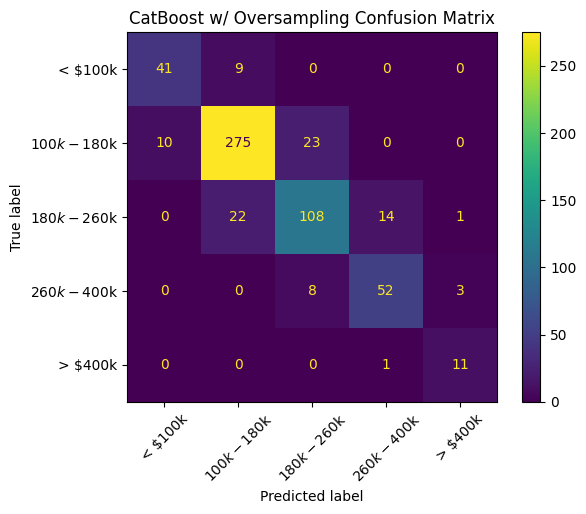

In [38]:
confusion=ConfusionMatrixDisplay(scores['OS CatBoost']['ConfusionMatrix'],display_labels=labels)
confusion.plot()
plt.title(f'CatBoost w/ Oversampling Confusion Matrix')
plt.xticks(rotation=45)
plt.show()

In [37]:
print(classification_report(y_test, os_cat_y_pred))

              precision    recall  f1-score   support

         0.0       0.80      0.82      0.81        50
         1.0       0.90      0.89      0.90       308
         2.0       0.78      0.74      0.76       145
         3.0       0.78      0.83      0.80        63
         4.0       0.73      0.92      0.81        12

    accuracy                           0.84       578
   macro avg       0.80      0.84      0.82       578
weighted avg       0.84      0.84      0.84       578



### Feature Engineering

In [57]:
#only numerical columns
nums=df.iloc[:,:33]
nums.columns

Index(['Lot Frontage', 'Lot Area', 'Year Built', 'Year Remod/Add',
       'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
       'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd',
       'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area',
       'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch',
       'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold'],
      dtype='str')

In [ ]:
#columns to drop
drop_num=['BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF','Low Qual Fin SF']

In [51]:
#categorical columns + target variable
cat_cols=df.drop(columns=nums)
cat_cols

,MS SubClass_20,MS SubClass_30,MS SubClass_40,MS SubClass_45,MS SubClass_50,MS SubClass_60,MS SubClass_70,MS SubClass_75,MS SubClass_80,MS SubClass_85,...,Fireplace Qu,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Overall Qual,Overall Cond,Price Bins
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,2.0,2.0,1.0,4.0,4.0,6,5,$180k-$260k
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,2.0,2.0,2.0,0.0,4.0,1.0,5,6,$100k-$180k
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,2.0,2.0,2.0,0.0,4.0,4.0,6,6,$100k-$180k
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,2.0,2.0,0.0,4.0,4.0,7,5,$180k-$260k
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,2.0,0.0,2.0,2.0,0.0,4.0,1.0,5,5,$180k-$260k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2883,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,5.0,2.0,2.0,2.0,0.0,4.0,0.0,6,6,$100k-$180k
2884,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,2.0,2.0,2.0,0.0,4.0,1.0,5,5,$100k-$180k
2885,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,5.0,3.0,5.0,5.0,0.0,4.0,1.0,5,5,$100k-$180k
2886,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,1.0,2.0,2.0,0.0,4.0,4.0,5,5,$100k-$180k


In [58]:
#feature engineering: Garage to Car Ratio
nums=nums.drop(columns=drop_num)
nums['Garage Car Ratio']=(nums['Garage Area']/nums['Garage Cars']).fillna(0)
nums

,Lot Frontage,Lot Area,Year Built,Year Remod/Add,Mas Vnr Area,Total Bsmt SF,1st Flr SF,2nd Flr SF,Gr Liv Area,Bsmt Full Bath,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Garage Car Ratio
0,141.0,31770,1960,1960,112.0,1080.0,1656,0,1656,1.0,...,210,62,0,0,0,0,0,5,2010,264.000000
1,80.0,11622,1961,1961,0.0,882.0,896,0,896,0.0,...,140,0,0,0,120,0,0,6,2010,730.000000
2,81.0,14267,1958,1958,108.0,1329.0,1329,0,1329,0.0,...,393,36,0,0,0,0,12500,6,2010,312.000000
3,93.0,11160,1968,1968,0.0,2110.0,2110,0,2110,1.0,...,0,0,0,0,0,0,0,4,2010,261.000000
4,74.0,13830,1997,1998,0.0,928.0,928,701,1629,0.0,...,212,34,0,0,0,0,0,3,2010,241.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2883,37.0,7937,1984,1984,0.0,1003.0,1003,0,1003,1.0,...,120,0,0,0,0,0,0,3,2006,294.000000
2884,74.0,8885,1983,1983,0.0,864.0,902,0,902,1.0,...,164,0,0,0,0,0,0,6,2006,242.000000
2885,62.0,10441,1992,1992,0.0,912.0,970,0,970,0.0,...,80,32,0,0,0,0,700,7,2006,0.000000
2886,77.0,10010,1974,1975,0.0,1389.0,1389,0,1389,1.0,...,240,38,0,0,0,0,0,4,2006,209.000000


In [61]:
fe_df=pd.concat([nums.reset_index(drop=True),cat_cols.reset_index(drop=True)],axis=1)
fe_df

,Lot Frontage,Lot Area,Year Built,Year Remod/Add,Mas Vnr Area,Total Bsmt SF,1st Flr SF,2nd Flr SF,Gr Liv Area,Bsmt Full Bath,...,Fireplace Qu,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Overall Qual,Overall Cond,Price Bins
0,141.0,31770,1960,1960,112.0,1080.0,1656,0,1656,1.0,...,1.0,0.0,2.0,2.0,1.0,4.0,4.0,6,5,$180k-$260k
1,80.0,11622,1961,1961,0.0,882.0,896,0,896,0.0,...,5.0,2.0,2.0,2.0,0.0,4.0,1.0,5,6,$100k-$180k
2,81.0,14267,1958,1958,108.0,1329.0,1329,0,1329,0.0,...,5.0,2.0,2.0,2.0,0.0,4.0,4.0,6,6,$100k-$180k
3,93.0,11160,1968,1968,0.0,2110.0,2110,0,2110,1.0,...,2.0,0.0,2.0,2.0,0.0,4.0,4.0,7,5,$180k-$260k
4,74.0,13830,1997,1998,0.0,928.0,928,701,1629,0.0,...,2.0,0.0,2.0,2.0,0.0,4.0,1.0,5,5,$180k-$260k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2883,37.0,7937,1984,1984,0.0,1003.0,1003,0,1003,1.0,...,5.0,2.0,2.0,2.0,0.0,4.0,0.0,6,6,$100k-$180k
2884,74.0,8885,1983,1983,0.0,864.0,902,0,902,1.0,...,5.0,2.0,2.0,2.0,0.0,4.0,1.0,5,5,$100k-$180k
2885,62.0,10441,1992,1992,0.0,912.0,970,0,970,0.0,...,5.0,3.0,5.0,5.0,0.0,4.0,1.0,5,5,$100k-$180k
2886,77.0,10010,1974,1975,0.0,1389.0,1389,0,1389,1.0,...,2.0,1.0,2.0,2.0,0.0,4.0,4.0,5,5,$100k-$180k


### Modeling: Catboost w/ Oversampling and Feature Engineering

In [66]:
#train/test split
fe_X = fe_df.iloc[:,:-1] #excluding  target var
fe_y = fe_df.iloc[:,-1:] #only categorical target var

#ordinal labeling of target variable
labels=['< $100k','$100k-$180k','$180k-$260k','$260k-$400k','> $400k']
encoder=OrdinalEncoder(categories=[labels])
fe_y=encoder.fit_transform(fe_y)

fe_X_train, fe_X_test, fe_y_train, fe_y_test = train_test_split(fe_X, fe_y, test_size=0.2,stratify=y,random_state=123)

In [67]:
fe_pipeline = pipelineIM([
    ('oversampling', RandomOverSampler(random_state=123)),
    ('catboost', CatBoostClassifier(random_state=123))
])

fe_pipeline.fit(fe_X_train, fe_y_train)

Learning rate set to 0.086804
0:	learn: 1.4629401	total: 52.3ms	remaining: 52.3s
1:	learn: 1.3432600	total: 70.6ms	remaining: 35.2s
2:	learn: 1.2452758	total: 77.7ms	remaining: 25.8s
3:	learn: 1.1541910	total: 84ms	remaining: 20.9s
4:	learn: 1.0793651	total: 90.2ms	remaining: 18s
5:	learn: 1.0155276	total: 96.5ms	remaining: 16s
6:	learn: 0.9581054	total: 103ms	remaining: 14.6s
7:	learn: 0.9087670	total: 109ms	remaining: 13.5s
8:	learn: 0.8653962	total: 115ms	remaining: 12.7s
9:	learn: 0.8283936	total: 121ms	remaining: 12s
10:	learn: 0.7976548	total: 126ms	remaining: 11.3s
11:	learn: 0.7653320	total: 132ms	remaining: 10.9s
12:	learn: 0.7335669	total: 138ms	remaining: 10.5s
13:	learn: 0.7078951	total: 144ms	remaining: 10.1s
14:	learn: 0.6834173	total: 151ms	remaining: 9.88s
15:	learn: 0.6608872	total: 157ms	remaining: 9.64s
16:	learn: 0.6421747	total: 163ms	remaining: 9.4s
17:	learn: 0.6243766	total: 168ms	remaining: 9.18s
18:	learn: 0.6065060	total: 174ms	remaining: 8.98s
19:	learn: 0.5

,steps,"[('oversampling', ...), ('catboost', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,123
,shrinkage,None


In [68]:
#predictions
fe_cat_y_pred = fe_pipeline.predict(fe_X_test)

#metrics; adding XGBoost scores to existing scores dictionary
scores['FE CatBoost']=dict()
scores['FE CatBoost']['Accuracy'] = accuracy_score(fe_y_test, fe_cat_y_pred)
scores['FE CatBoost']['Precision'] = precision_score(fe_y_test, fe_cat_y_pred,average='macro')
scores['FE CatBoost']['Recall'] = recall_score(fe_y_test, fe_cat_y_pred,average='macro')
scores['FE CatBoost']['F1'] = f1_score(fe_y_test, fe_cat_y_pred,average='macro')
scores['FE CatBoost']['ConfusionMatrix']=confusion_matrix(fe_y_test,fe_cat_y_pred)

#table of metrics for previous models + XGB
display(HTML(tabulate.tabulate(list(map(lambda x: [x[0]]+x[1],zip(scores.keys(),map(lambda x: list(x.values()),scores.values())))), 
                               tablefmt='html',
                               headers=[" "]+list(next(iter(scores.items()))[1].keys()))))

,Accuracy,Precision,Recall,F1,ConfusionMatrix
AdaBoost,0.740484,0.586698,0.492471,0.508367,[[ 12 37 1 0 0] [ 3 278 27 0 0] [ 0 42 97 6 0] [ 0 0 22 41 0] [ 0 0 0 12 0]]
CatBoost,0.842561,0.806633,0.734278,0.764113,[[ 34 16 0 0 0] [ 8 285 15 0 0] [ 0 25 112 7 1] [ 0 0 12 50 1] [ 0 0 0 6 6]]
OS CatBoost,0.842561,0.797809,0.83995,0.816605,[[ 41 9 0 0 0] [ 10 275 23 0 0] [ 0 22 108 14 1] [ 0 0 8 52 3] [ 0 0 0 1 11]]
FE CatBoost,0.83737,0.776498,0.806601,0.790533,[[ 40 10 0 0 0] [ 15 272 21 0 0] [ 0 21 110 13 1] [ 0 0 7 53 3] [ 0 0 0 3 9]]


In [69]:
print(classification_report(fe_y_test, fe_cat_y_pred))

              precision    recall  f1-score   support

         0.0       0.73      0.80      0.76        50
         1.0       0.90      0.88      0.89       308
         2.0       0.80      0.76      0.78       145
         3.0       0.77      0.84      0.80        63
         4.0       0.69      0.75      0.72        12

    accuracy                           0.84       578
   macro avg       0.78      0.81      0.79       578
weighted avg       0.84      0.84      0.84       578



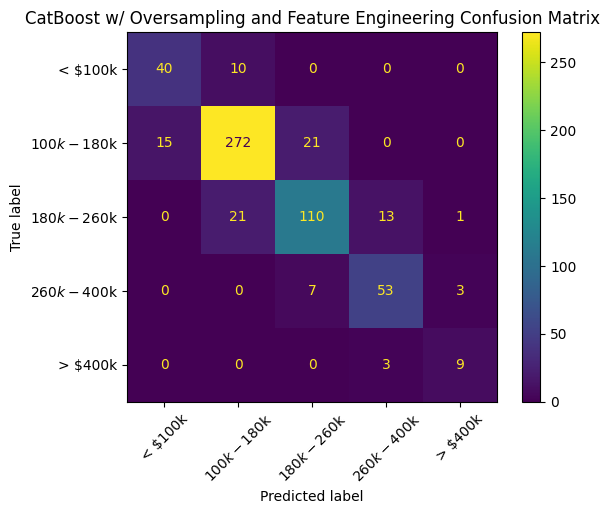

In [71]:
confusion=ConfusionMatrixDisplay(scores['FE CatBoost']['ConfusionMatrix'],display_labels=labels)
confusion.plot()
plt.title(f'CatBoost w/ Oversampling and Feature Engineering Confusion Matrix')
plt.xticks(rotation=45)
plt.show()

### Appending Metrics to Scores File

In [70]:
scores_file=pd.DataFrame.from_dict(scores,orient='index')
scores_file.to_csv('cap2_metrics.csv', mode='a', header=False)